# Домашнее задание №3
### Третьякова Юля Б06-303

### Часть 1

С помощью команд:

```
show-snps -ClrT ecoli_full_filt1.delta > ecoli_full_filt1.snps
head -20 ecoli_full_filt1.snps
```
в командной строке WSL из файла выравнивания `ecoli_full_filt1.delta` был получен SNP-файл `ecoli_full_filt1.snps`.

Команда `show-snps` извлекает координаты различий между двумя геномами из результата выравнивания.

*Все файлы, которые будут использоваться, загружены на гитхаб.

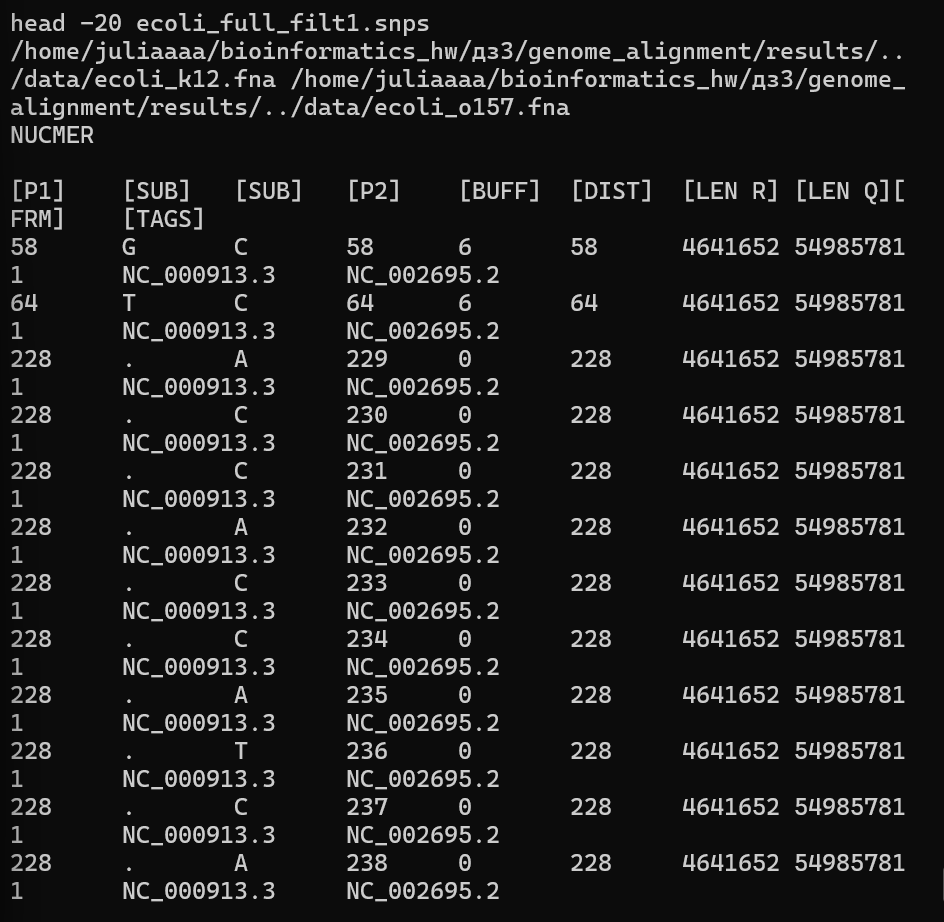

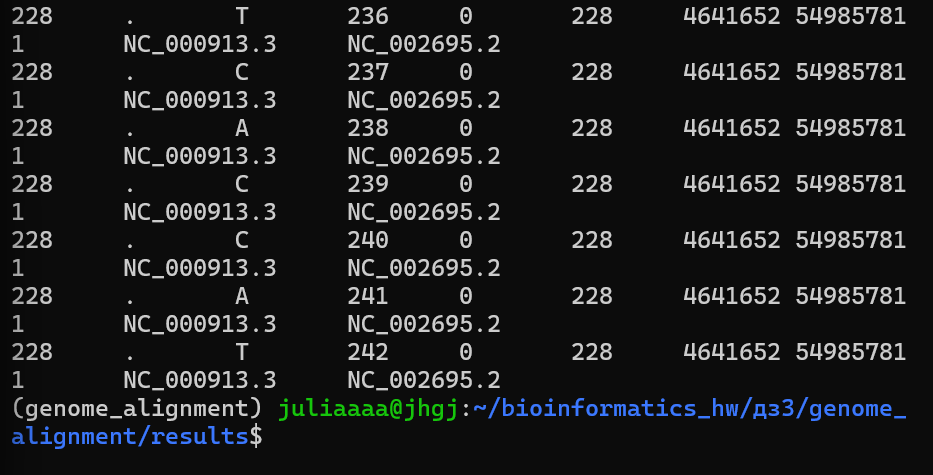

Видим столбцы:

[P1] [SUB] [SUB] [P2] [BUFF] [DIST] [LEN R] [LEN Q] [FRM] [TAGS]

Их смысл:

*   P1 — позиция в первом (reference) геноме
*   первый SUB — нуклеотид в reference,
*   второй SUB — нуклеотид в query.
*   P2 — позиция во втором (query) геноме
*   BUFF — расстояние до следующего различия внутри текущего выровненного блока
*   DIST — расстояние от начала текущего выровненного блока
*   LEN R — длина reference-последовательности
*   LEN Q — длина query-последовательности
*   FRM — ориентация выравнивания
*   TAGS — имена сравниваемых последовательностей

После работы в WSL получили файлы .delta — внутренние результаты выравнивания MUMmer.
Для того чтобы работать с этими файлами здесь в python, перевели их в текстовые таблицы:

*   .coords — таблица координат выровненных блоков
*   .snps — таблица различий между геномами

Команды:

```
show-coords -THrcl ecoli_full_filt1.delta > ecoli_full_filt1.coords
show-coords -THrcl ecoli_full_filt2.delta > ecoli_full_filt2.coords
show-coords -THrcl ecoli_full_multi.delta > ecoli_full_multi.coords

show-snps -ClrTH ecoli_full_filt1.delta > ecoli_full_filt1.snps
show-snps -ClrTH ecoli_full_filt2.delta > ecoli_full_filt2.snps
show-snps -ClrTH ecoli_full_multi.delta > ecoli_full_multi.snps
```

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

In [ ]:
# функция для чтения .coords

def read_coords(filename):
    cols = [
        "S1", "E1", "S2", "E2",
        "LEN1", "LEN2", "IDY",
        "LENR", "LENQ", "COVR", "COVQ",
        "TAGR", "TAGQ"
    ]

    df = pd.read_csv(filename, sep="\t", header=None)
    df.columns = cols[:df.shape[1]]

    numeric_cols = ["S1", "E1", "S2", "E2", "LEN1", "LEN2", "IDY", "LENR", "LENQ", "COVR", "COVQ"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

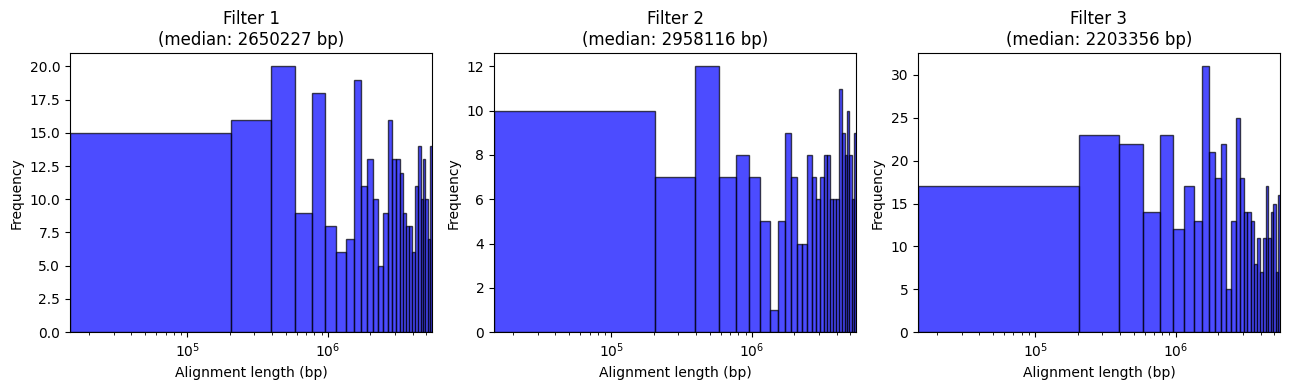

In [ ]:
# строим гистограммы длин выравниваний

coords_files = [
    ("ecoli_full_filt1.coords", "Filter 1"),
    ("ecoli_full_filt2.coords", "Filter 2"),
    ("ecoli_full_multi.coords", "Filter 3"),
]

# сначала соберём все значения E2, чтобы у всех трёх графиков были одинаковые интервалы
all_values = []

for fname, _ in coords_files:
    df = read_coords(fname)
    vals = df["E2"].dropna()
    vals = vals[vals > 0]
    all_values.extend(vals.tolist())

xmin = min(all_values)
xmax = max(all_values)

# линейные bins, а не logspace
bins = np.linspace(xmin, xmax, 30)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (fname, title) in zip(axes, coords_files):
    df = read_coords(fname)

    values = df["E2"].dropna()
    values = values[values > 0]

    ax.hist(values, bins=bins, edgecolor="black", color="blue", alpha=0.7)
    ax.set_xscale("log")
    ax.set_xlim(xmin, xmax)

    ax.set_xlabel("Конечная координата блока в query-геноме (bp)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{title}\n(median: {int(values.median())} bp)")

plt.tight_layout()
plt.show()

Построили гистограммы распределения конечных координат выровненных блоков во втором геноме (`E2`) после трёх вариантов фильтрации.

Фильтр 1: 1-к-1 соответствия, идентичность >90%

Фильтр 2: 1-к-1, длина блока ≥5000, т.е. может оставить длинные, но менее идентичные участки.

Фильтр 3: множественные соответствия, идентичность >85%, сохраняет более широкий набор совпадений, включая менее однозначные и повторяющиеся участки.

Эти графики показывают, как по хромосоме распределены блоки, прошедшие разные варианты отбора.

По ним видно, что фильтр 2 даёт более жёсткий отбор именно по длине блоков, поскольку исключает короткие участки. Фильтр 1, в свою очередь, оставляет только однозначные соответствия 1-к-1 с высокой идентичностью и поэтому использовался далее для основной аннотации SNP. Фильтр 3 сохраняет более широкий набор совпадений, включая менее однозначные.

In [61]:
# функция для чтения .snps (читаем SNP-файл построчно)

def read_snps(filename):
    positions = []
    ref_len = None

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = re.split(r"\s+", line)

            if len(parts) < 8:
                continue

            try:
                p1 = int(parts[0])
                sub1 = parts[1].upper()
                sub2 = parts[2].upper()
                len_r = int(parts[6])
            except:
                continue

            # оставляем только чистые SNP
            if sub1 in {"A", "T", "G", "C"} and sub2 in {"A", "T", "G", "C"}:
                positions.append(p1)
                ref_len = len_r

    return np.array(positions), ref_len

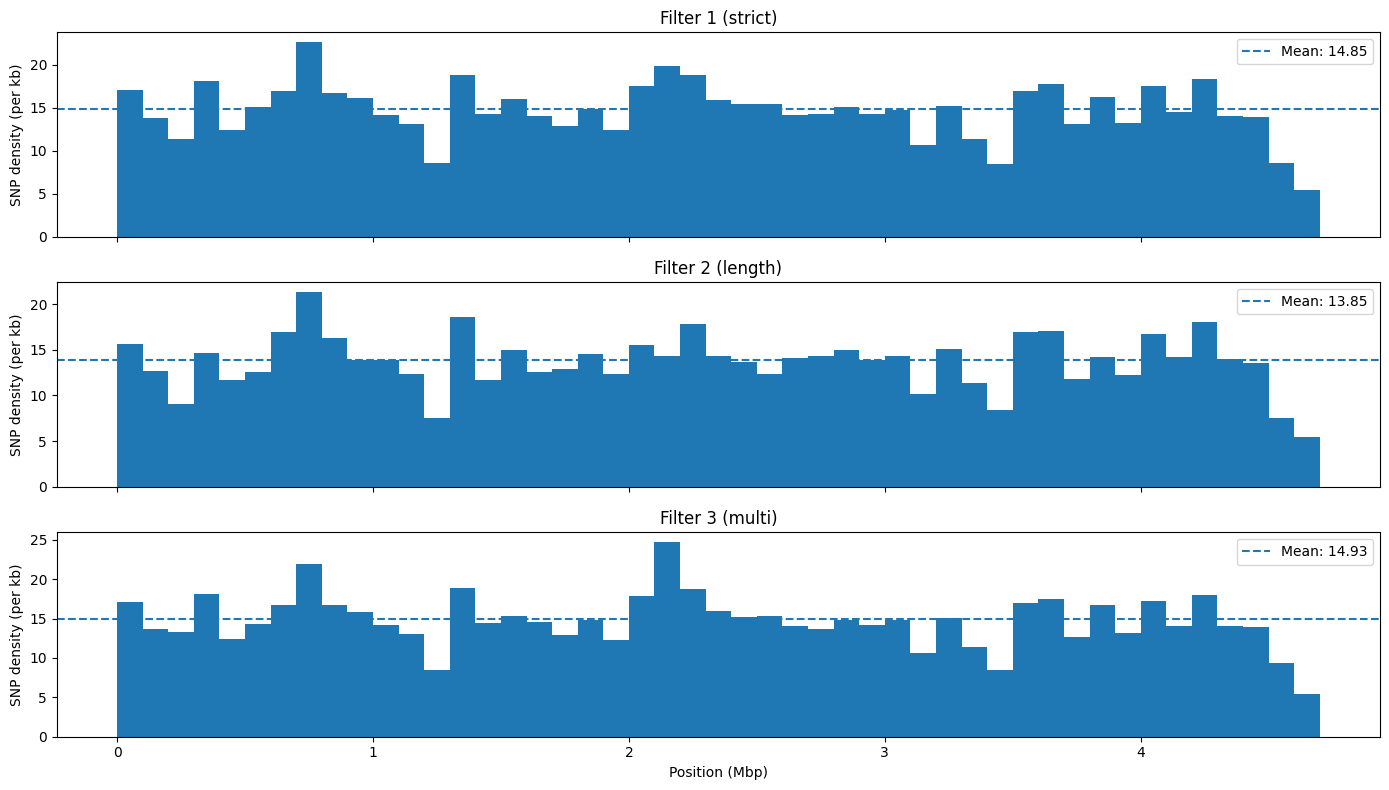

In [62]:
# строим графики плотности SNP

snps_files = [
    ("ecoli_full_filt1.snps", "Filter 1 (strict)"),
    ("ecoli_full_filt2.snps", "Filter 2 (length)"),
    ("ecoli_full_multi.snps", "Filter 3 (multi)"),
]

window = 100000  # окно 100 kb

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, (fname, title) in zip(axes, snps_files):
    positions, ref_len = read_snps(fname)

    bins = np.arange(0, ref_len + window, window)
    counts, edges = np.histogram(positions, bins=bins)

    density = counts / (window / 1000)   # SNP на 1 kb

    x = edges[:-1] / 1e6
    width = window / 1e6

    ax.bar(x, density, width=width, align="edge")

    mean_density = len(positions) / (ref_len / 1000)
    ax.axhline(mean_density, linestyle="--", label=f"Mean: {mean_density:.2f}")

    ax.set_ylabel("SNP density (per kb)")
    ax.set_title(title)
    ax.legend()

axes[-1].set_xlabel("Position (Mbp)")
plt.tight_layout()
plt.show()

Фильтры заметно влияют на набор сохраняемых выравниваний: фильтр 2 делает результат более строгим за счёт удаления коротких участков, а фильтр 3 сохраняет больше совпадений, включая менее однозначные.  

По графикам плотности SNP видно, что различия между геномами распределены по хромосоме довольно равномерно, хотя есть отдельные участки с повышенной плотностью SNP. Средние значения для трёх фильтров близки, значит общая картина различий устойчива.  

Итог: сравниваемые геномы близки между собой, но содержат локальные области повышенных различий, которые удаётся выявить с помощью выравнивания и SNP-анализа.

### Часть 2

Был скачан GenBank-файл генома *E. coli* `K-12 MG1655` с NCBI в формате GBFF, т.е. файл содержит как саму последовательность генома, так и его аннотацию, что нужно для определения положения SNP относительно генов и кодирующих областей.


In [28]:
!pip -q install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 67.4 MB/s eta 0:00:00


In [29]:
import re
import pandas as pd
from Bio import SeqIO

In [32]:
# читаем файл ecoli_full_filt1.snps и оставляем только такие строки, где в reference стоит нормальная буква A/T/G/C, в alternative тоже стоит A/T/G/C.
# то есть выкидываем строки с точкой

def read_snp_file(filename):
    rows = []

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = re.split(r"\s+", line)

            if len(parts) < 4:
                continue

            try:
                p1 = int(parts[0])   # позиция в reference
                p2 = int(parts[3])   # позиция в query
            except:
                continue

            ref_nt = parts[1].upper()
            alt_nt = parts[2].upper()

            rows.append({
                "pos_ref": p1,
                "ref_nt": ref_nt,
                "alt_nt": alt_nt,
                "pos_query": p2
            })

    return pd.DataFrame(rows)


snps_raw = read_snp_file("ecoli_full_filt1.snps")

true_snps = snps_raw[
    snps_raw["ref_nt"].isin(list("ATGC")) &
    snps_raw["alt_nt"].isin(list("ATGC"))
].copy()

print("Всего записей в SNP-файле:", len(snps_raw))
print("Чистых SNP:", len(true_snps))
print("Не-SNP (indel / прочее):", len(snps_raw) - len(true_snps))

true_snps.head()

Всего записей в SNP-файле: 73161
Чистых SNP: 68920
Не-SNP (indel / прочее): 4241


,pos_ref,ref_nt,alt_nt,pos_query
0,58,G,C,58
1,64,T,C,64
21,393,T,G,410
22,559,T,C,576
23,588,G,A,605


Из исходного `.snps`-файла были отобраны только однонуклеотидные замены. Записи, содержащие символ `.`, были исключены, так как они соответствуют вставкам или делециям. Это позволит дальше анализировать именно SNP, а не все типы различий подряд.

In [33]:
record = SeqIO.read("genomic.gbff", "genbank")

print("ID записи:", record.id)
print("Длина генома:", len(record.seq))
print("Число аннотированных features:", len(record.features))

ID записи: U00096.3
Длина генома: 4641652
Число аннотированных features: 9285


Мы читаем файл genomic.gbff как GenBank-запись. `record` теперь содержит: саму последовательность генома K-12 и аннотацию по геному (карту генов).

In [34]:
from collections import Counter

feature_counts = Counter(feat.type for feat in record.features)
pd.DataFrame(feature_counts.items(), columns=["feature_type", "count"]).sort_values("count", ascending=False)

,feature_type,count
1,gene,4651
2,CDS,4318
4,ncRNA,108
6,tRNA,86
3,mobile_element,50
7,misc_feature,48
5,rRNA,22
0,source,1
8,rep_origin,1


После загрузки GenBank-файла был выполнен просмотр состава аннотации. В файле присутствуют признаки типов gene, CDS, tRNA, rRNA, ncRNA и другие. Значит, аннотация успешно считана и содержит координаты кодирующих последовательностей, необходимые для дальнейшей интерпретации SNP.

Теперь делаем таблицу только по CDS, потому что именно для CDS можно определять синонимичность и аминокислотные замены.

In [35]:
def get_qual(feature, key):
    return feature.qualifiers.get(key, [""])[0]


cds_rows = []

for feat in record.features:
    if feat.type != "CDS":
        continue

    start = int(feat.location.start) + 1   # делаем координаты 1-based
    end = int(feat.location.end)
    strand = feat.location.strand

    cds_rows.append({
        "start": start,
        "end": end,
        "strand": strand,
        "gene": get_qual(feat, "gene"),
        "locus_tag": get_qual(feat, "locus_tag"),
        "product": get_qual(feat, "product"),
        "protein_id": get_qual(feat, "protein_id")
    })

cds_df = pd.DataFrame(cds_rows)

print("Число CDS:", len(cds_df))
cds_df.head()

Число CDS: 4318


,start,end,strand,gene,locus_tag,product,protein_id
0,190,255,1,thrL,b0001,thr operon leader peptide,AAC73112.1
1,337,2799,1,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,AAC73113.1
2,2801,3733,1,thrB,b0003,homoserine kinase,AAC73114.1
3,3734,5020,1,thrC,b0004,threonine synthase,AAC73115.1
4,5234,5530,1,yaaX,b0005,DUF2502 domain-containing protein YaaX,AAC73116.1


Из GenBank-аннотации была извлечена таблица кодирующих последовательностей (CDS), содержащая координаты начала и конца, направление на цепи, имя гена, `locus_tag`, описание продукта и идентификатор белка. Эта таблица используется для определения, попадает ли SNP в кодирующую область и к какой CDS она относится.

In [36]:
def annotate_position(pos):
    hits = cds_df[(cds_df["start"] <= pos) & (cds_df["end"] >= pos)]

    if len(hits) == 0:
        return pd.Series({
            "region_type": "intergenic",
            "gene": "",
            "locus_tag": "",
            "product": "",
            "strand": None,
            "cds_start": None,
            "cds_end": None
        })

    row = hits.iloc[0]

    return pd.Series({
        "region_type": "CDS",
        "gene": row["gene"],
        "locus_tag": row["locus_tag"],
        "product": row["product"],
        "strand": row["strand"],
        "cds_start": row["start"],
        "cds_end": row["end"]
    })


annotated_snps = true_snps.copy()
annotated_snps[["region_type", "gene", "locus_tag", "product", "strand", "cds_start", "cds_end"]] = (
    annotated_snps["pos_ref"].apply(annotate_position)
)

annotated_snps.head(10)

,pos_ref,ref_nt,alt_nt,pos_query,region_type,gene,locus_tag,product,strand,cds_start,cds_end
0,58,G,C,58,intergenic,,,,NaN,NaN,NaN
1,64,T,C,64,intergenic,,,,NaN,NaN,NaN
21,393,T,G,410,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0
22,559,T,C,576,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0
23,588,G,A,605,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0
24,621,T,C,638,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0
25,669,G,A,686,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0
26,690,C,T,707,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0
27,774,T,C,791,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0
28,828,C,T,845,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0


Для каждой SNP по координате в референсном геноме было определено её положение относительно кодирующих последовательностей. Если позиция попадала внутрь CDS, к SNP добавлялись имя гена, locus_tag, описание продукта, направление цепи и координаты CDS. Если SNP не попадала ни в одну CDS, она классифицировалась как `intergenic`, то есть вне кодирующих областей.

In [40]:
from Bio.Seq import Seq

# соответствие 1-буквенных аминокислот 3-буквенным
aa3 = {
    "A": "Ala", "R": "Arg", "N": "Asn", "D": "Asp", "C": "Cys",
    "Q": "Gln", "E": "Glu", "G": "Gly", "H": "His", "I": "Ile",
    "L": "Leu", "K": "Lys", "M": "Met", "F": "Phe", "P": "Pro",
    "S": "Ser", "T": "Thr", "W": "Trp", "Y": "Tyr", "V": "Val",
    "*": "Ter"
}

comp = {"A": "T", "T": "A", "G": "C", "C": "G"}


def get_qual(feature, key):
    return feature.qualifiers.get(key, [""])[0]

# делаем словарь: по координатам и имени гена быстро находим нужную CDS-feature
feature_map = {}

for feat in record.features:
    if feat.type != "CDS":
        continue

    start = int(feat.location.start) + 1
    end = int(feat.location.end)
    gene = get_qual(feat, "gene")
    locus_tag = get_qual(feat, "locus_tag")

    key = (start, end, gene, locus_tag)
    feature_map[key] = feat


def genomic_pos_to_cds_index(feature, pos):
    """
    Возвращает индекс позиции SNP внутри CDS
    в координатах самой кодирующей последовательности (0-based).
    Учитывает направление цепи.
    """
    parts = list(getattr(feature.location, "parts", [feature.location]))
    strand = feature.location.strand

    if strand == 1:
        parts = sorted(parts, key=lambda p: int(p.start))
        offset = 0
        for part in parts:
            start = int(part.start) + 1
            end = int(part.end)

            if start <= pos <= end:
                return offset + (pos - start)

            offset += (end - start + 1)

    elif strand == -1:
        parts = sorted(parts, key=lambda p: int(p.start), reverse=True)
        offset = 0
        for part in parts:
            start = int(part.start) + 1
            end = int(part.end)

            if start <= pos <= end:
                return offset + (end - pos)

            offset += (end - start + 1)

    return None


def translate_codon(codon):
    return str(Seq(codon).translate(table=11))   # бактериальный генетический код


def make_aa_change(aa_ref, aa_pos, aa_alt):
    return f"p.{aa3.get(aa_ref, aa_ref)}{aa_pos}{aa3.get(aa_alt, aa_alt)}"

print("Число CDS в feature_map:", len(feature_map))

Число CDS в feature_map: 4318


Подготовили инструменты для анализа CDS-SNP:

*   находим нужную CDS;
*   определяем, где SNP лежит внутри CDS;
*   достаём кодон;
*   умеем переводить кодон в аминокислоту.

In [41]:
def annotate_coding_effect(row):
    # если SNP не в CDS, сразу возвращаем intergenic
    if row["region_type"] != "CDS":
        return pd.Series({
            "effect_type": "intergenic",
            "aa_change": "",
            "ref_codon": "",
            "alt_codon": "",
            "ref_aa": "",
            "alt_aa": "",
            "aa_pos": None,
            "functional_note": "вне CDS, возможное влияние может быть связано с регуляторными областями"
        })

    key = (int(row["cds_start"]), int(row["cds_end"]), row["gene"], row["locus_tag"])
    feature = feature_map.get(key, None)

    if feature is None:
        return pd.Series({
            "effect_type": "unknown",
            "aa_change": "",
            "ref_codon": "",
            "alt_codon": "",
            "ref_aa": "",
            "alt_aa": "",
            "aa_pos": None,
            "functional_note": "не удалось сопоставить SNP с CDS-feature"
        })

    pos = int(row["pos_ref"])
    cds_index = genomic_pos_to_cds_index(feature, pos)

    if cds_index is None:
        return pd.Series({
            "effect_type": "unknown",
            "aa_change": "",
            "ref_codon": "",
            "alt_codon": "",
            "ref_aa": "",
            "alt_aa": "",
            "aa_pos": None,
            "functional_note": "не удалось определить положение SNP внутри CDS"
        })

    # CDS уже в правильной кодирующей ориентации
    cds_seq = str(feature.extract(record.seq)).upper()

    if cds_index >= len(cds_seq):
        return pd.Series({
            "effect_type": "unknown",
            "aa_change": "",
            "ref_codon": "",
            "alt_codon": "",
            "ref_aa": "",
            "alt_aa": "",
            "aa_pos": None,
            "functional_note": "индекс SNP выходит за границы CDS"
        })

    # референсная буква в кодирующей последовательности
    ref_base_cds = cds_seq[cds_index]

    # альтернативная буква
    alt_base = row["alt_nt"].upper()

    # если ген на обратной цепи, надо взять комплементарную замену
    if feature.location.strand == -1:
        alt_base_cds = comp[alt_base]
    else:
        alt_base_cds = alt_base

    # находим кодон
    codon_start = (cds_index // 3) * 3
    codon_pos = cds_index % 3

    ref_codon = cds_seq[codon_start:codon_start + 3]

    if len(ref_codon) != 3:
        return pd.Series({
            "effect_type": "unknown",
            "aa_change": "",
            "ref_codon": ref_codon,
            "alt_codon": "",
            "ref_aa": "",
            "alt_aa": "",
            "aa_pos": None,
            "functional_note": "неполный кодон на границе CDS"
        })

    alt_codon_list = list(ref_codon)
    alt_codon_list[codon_pos] = alt_base_cds
    alt_codon = "".join(alt_codon_list)

    ref_aa = translate_codon(ref_codon)
    alt_aa = translate_codon(alt_codon)
    aa_pos = cds_index // 3 + 1

    # определяем тип эффекта
    if ref_aa == alt_aa:
        effect_type = "synonymous"
        aa_change = make_aa_change(ref_aa, aa_pos, alt_aa)
        functional_note = "аминокислотная последовательность не меняется, прямой белковый эффект не ожидается"

    elif alt_aa == "*":
        effect_type = "nonsense"
        aa_change = make_aa_change(ref_aa, aa_pos, alt_aa)
        functional_note = "появляется стоп-кодон, возможна укороченная форма белка"

    elif ref_aa == "*":
        effect_type = "stop_lost"
        aa_change = make_aa_change(ref_aa, aa_pos, alt_aa)
        functional_note = "исчезает стоп-кодон, возможно удлинение белка"

    else:
        effect_type = "nonsynonymous"
        aa_change = make_aa_change(ref_aa, aa_pos, alt_aa)
        functional_note = "замена меняет аминокислоту и потенциально может влиять на функцию белка"

    return pd.Series({
        "effect_type": effect_type,
        "aa_change": aa_change,
        "ref_codon": ref_codon,
        "alt_codon": alt_codon,
        "ref_aa": ref_aa,
        "alt_aa": alt_aa,
        "aa_pos": aa_pos,
        "functional_note": functional_note
    })


annotated_snps[
    ["effect_type", "aa_change", "ref_codon", "alt_codon", "ref_aa", "alt_aa", "aa_pos", "functional_note"]
] = annotated_snps.apply(annotate_coding_effect, axis=1)

annotated_snps.head(15)

,pos_ref,ref_nt,alt_nt,pos_query,region_type,gene,locus_tag,product,strand,cds_start,cds_end,effect_type,aa_change,ref_codon,alt_codon,ref_aa,alt_aa,aa_pos,functional_note
0,58,G,C,58,intergenic,,,,NaN,NaN,NaN,intergenic,,,,,,NaN,"вне CDS, возможное влияние может быть связано ..."
1,64,T,C,64,intergenic,,,,NaN,NaN,NaN,intergenic,,,,,,NaN,"вне CDS, возможное влияние может быть связано ..."
21,393,T,G,410,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0,synonymous,p.Arg19Arg,CGT,CGG,R,R,19.0,"аминокислотная последовательность не меняется,..."
22,559,T,C,576,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0,synonymous,p.Leu75Leu,TTG,CTG,L,L,75.0,"аминокислотная последовательность не меняется,..."
23,588,G,A,605,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0,synonymous,p.Gly84Gly,GGG,GGA,G,G,84.0,"аминокислотная последовательность не меняется,..."
24,621,T,C,638,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0,synonymous,p.Asp95Asp,GAT,GAC,D,D,95.0,"аминокислотная последовательность не меняется,..."
25,669,G,A,686,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0,synonymous,p.Leu111Leu,TTG,TTA,L,L,111.0,"аминокислотная последовательность не меняется,..."
26,690,C,T,707,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0,synonymous,p.Ile118Ile,ATC,ATT,I,I,118.0,"аминокислотная последовательность не меняется,..."
27,774,T,C,791,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0,synonymous,p.Thr146Thr,ACT,ACC,T,T,146.0,"аминокислотная последовательность не меняется,..."
28,828,C,T,845,CDS,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1,1.0,337.0,2799.0,synonymous,p.Thr164Thr,ACC,ACT,T,T,164.0,"аминокислотная последовательность не меняется,..."


Для SNP, попавших в CDS, был определён затронутый кодон, после чего сравнивались референсная и альтернативная аминокислоты. На основании этого замены классифицировались как `synonymous`, `nonsynonymous`, `nonsense` или `stop_lost`.

Для SNP вне CDS сохранялась категория `intergenic`, которая использовалась как обозначение позиций, не попавших в кодирующие области.


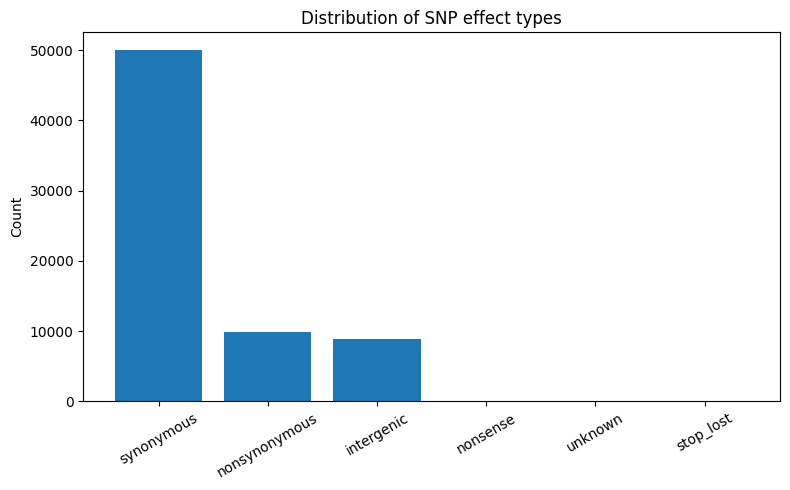

In [49]:
effect_counts = annotated_snps["effect_type"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(effect_counts.index, effect_counts.values)
plt.ylabel("Count")
plt.title("Distribution of SNP effect types")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

После аннотации была построена диаграмма распределения SNP по типам эффекта. Наибольшую долю составили синонимичные замены, далее следуют несинонимичные SNP и позиции вне кодирующих областей. Это показывает, что значительная часть нуклеотидных различий не меняет аминокислотную последовательность белков, хотя заметная доля замен всё же потенциально может влиять на функцию белковых продуктов.

In [50]:
gene_counts = (
    annotated_snps[annotated_snps["region_type"] == "CDS"]
    .groupby(["gene", "locus_tag", "product"])
    .size()
    .reset_index(name="snp_count")
    .sort_values("snp_count", ascending=False)
)

top10_genes = gene_counts.head(10)
top10_genes

,gene,locus_tag,product,snp_count
2676,ybgQ,b0718,putative fimbrial usher protein YbgQ,430
2960,yeeJ,b1978,inverse autotransporter adhesin,250
2674,ybgO,b0716,putative fimbrial protein YbgO,218
2982,yehI,b2118,DUF4132 domain-containing protein YehI,191
2675,ybgP,b0717,putative fimbrial chaperone YbgP,165
2811,ydbA,b4492,"putative outer membrane protein, N-terminal fr...",164
3343,yjgL,b4253,protein YjgL,139
3012,yfaL,b2233,putative autotransporter adhesin YfaL,139
600,entF,b0586,apo-serine activating enzyme,131
1383,metH,b4019,cobalamin-dependent methionine synthase,109


Для выявления наиболее вариабельных кодирующих участков была составлена таблица 10 генов с наибольшим числом SNP внутри CDS.


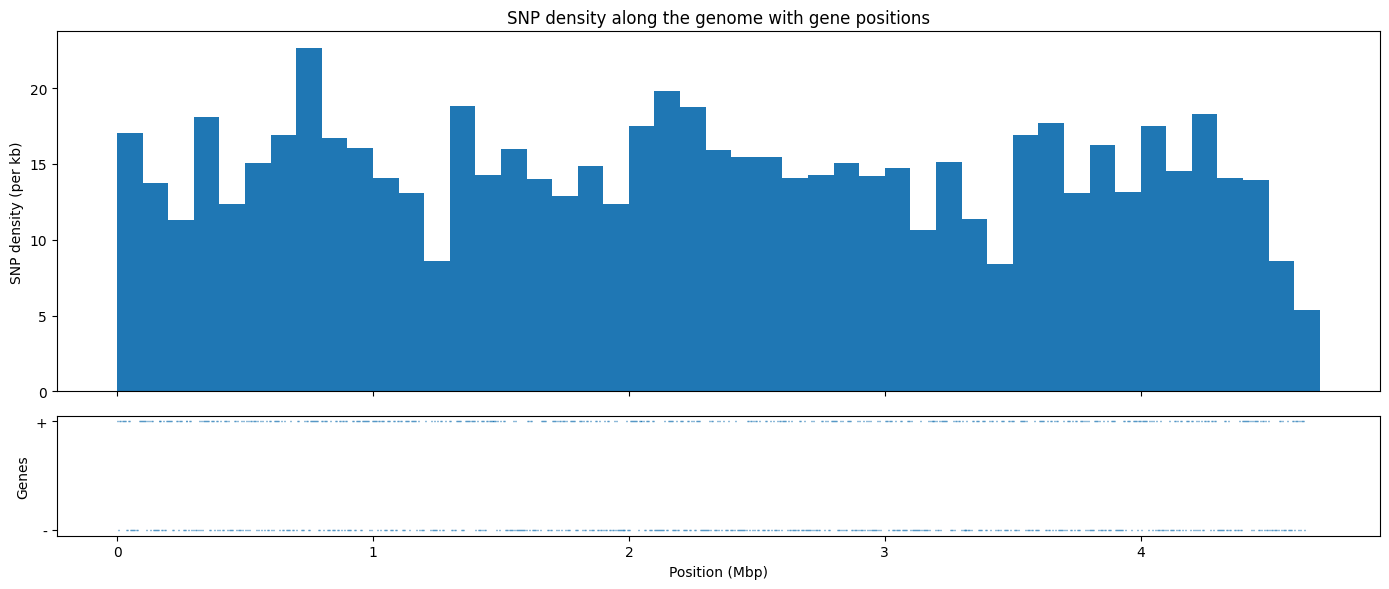

In [52]:
# берём только чистые SNP-позиции
positions = annotated_snps["pos_ref"].values

genome_len = len(record.seq)
window = 100000

bins = np.arange(0, genome_len + window, window)
counts, edges = np.histogram(positions, bins=bins)
density = counts / (window / 1000)   # SNP на 1 kb

# для генной дорожки возьмём CDS
genes_plot = cds_df.copy()

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 6), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# верхний график — плотность SNP
x = edges[:-1] / 1e6
width = window / 1e6
ax1.bar(x, density, width=width, align="edge")
ax1.set_ylabel("SNP density (per kb)")
ax1.set_title("SNP density along the genome with gene positions")

# нижний график — гены
for _, row in genes_plot.iterrows():
    y = 1 if row["strand"] == 1 else 0.5
    ax2.hlines(y, row["start"] / 1e6, row["end"] / 1e6, linewidth=1)

ax2.set_yticks([0.5, 1.0])
ax2.set_yticklabels(["-", "+"])
ax2.set_xlabel("Position (Mbp)")
ax2.set_ylabel("Genes")

plt.tight_layout()
plt.show()

Для визуализации распределения SNP вдоль генома был построен график плотности SNP по окнам 100 kb. Под ним нанесена дорожка кодирующих последовательностей (CDS), показывающая их положение на прямой и обратной цепях.

### Выводы

SNP были сопоставлены с аннотацией референсного генома *E. coli* K-12 из GenBank-файла. Для каждой замены определялось, попадает ли она в кодирующую область. Если SNP находилась внутри CDS, дальше для неё уже определялись затронутый кодон, тип эффекта (`synonymous`, `nonsynonymous`, `nonsense`, `stop_lost`) и аминокислотная замена.

По диаграмме распределения типов SNP видно, что больше всего встречается синонимичных замен. Это показывает, что значительная часть различий между геномами есть на уровне нуклеотидов, но не приводит к изменению аминокислотной последовательности белков. При этом заметная доля SNP относится к несинонимичным, то есть такие замены уже могут потенциально влиять на свойства белков и функции соответствующих генов.

График плотности SNP вдоль генома показал, что различия распределены по хромосоме не совсем равномерно: есть участки, где SNP накапливаются заметно сильнее. Дополнительно была составлена таблица топ-10 генов с наибольшим числом SNP в кодирующих областях. В итоге удалось не просто перечислить найденные замены, а связать их с конкретными CDS и выделить наиболее вариабельные участки генома.

### Часть 3

Для части 3 я выбрала анализ SNP в генах, связанных с устойчивостью к антибиотикам. Такой выбор опирается на статьи по *E. coli* O157:H7: в них показано, что у этого штамма есть выраженная геномная вариабельность, а также обсуждаются особенности, связанные с антибиотикорезистентностью и появлением резистентных вариантов по сравнению с K-12.

Поэтому сначала собираем список генов-кандидатов, связанных с устойчивостью к антибиотикам, а затем дополнительно использован поиск по ключевым словам в аннотации белковых продуктов (`efflux`, `antibiotic resistance`, `tetracycline`, `chloramphenicol` и др.). После этого из общей аннотированной таблицы SNP были отбираем только те замены, которые попали в эти гены или в белки с соответствующими признаками. Далее оставляем только потенциально значимые варианты (`nonsynonymous`, `nonsense`, `stop_lost`), то есть такие SNP, которые могут менять белковый продукт.

Собираем «интересные» гены устойчивости к антибиотикам (AR-гены):

In [53]:
ar_gene_panel = {
    "acrB", "arnA", "emrA", "macA", "marA", "mdtH", "mdtO",
    "pmrD", "rarD", "yfbH", "yjcP", "yjcR",
    "aadA1", "tetA", "tetB", "tetC", "sul1", "sul2",
    "catA1", "qnrA", "blaTEM", "blaCTX-M", "fsr", "ais"
}

# ключевые слова по product, чтобы не потерять гены,
# если короткое имя в колонке gene пустое или криво записано
ar_keywords = [
    "multidrug", "efflux", "antibiotic resistance",
    "tetracycline", "quinolone", "chloramphenicol",
    "sulfonamide", "polymyxin", "cephalosporin",
    "ampicillin", "macrolide", "fosfomycin"
]

pattern = "|".join(ar_keywords)

ar_snps = annotated_snps[
    annotated_snps["gene"].isin(ar_gene_panel) |
    annotated_snps["product"].fillna("").str.contains(pattern, case=False, regex=True)
].copy()

print("Всего SNP в AR-кандидатах:", len(ar_snps))
ar_snps[["pos_ref", "gene", "product", "effect_type", "aa_change"]].head(15)

Всего SNP в AR-кандидатах: 921


,pos_ref,gene,product,effect_type,aa_change
7553,481276,acrB,multidrug efflux pump RND permease AcrB,nonsynonymous,p.Ser1043Asn
7554,481575,acrB,multidrug efflux pump RND permease AcrB,synonymous,p.Ile943Ile
7555,482088,acrB,multidrug efflux pump RND permease AcrB,synonymous,p.Tyr772Tyr
7556,482373,acrB,multidrug efflux pump RND permease AcrB,synonymous,p.Ala677Ala
7557,482376,acrB,multidrug efflux pump RND permease AcrB,synonymous,p.Thr676Thr
7558,482487,acrB,multidrug efflux pump RND permease AcrB,synonymous,p.Gly639Gly
7559,482643,acrB,multidrug efflux pump RND permease AcrB,synonymous,p.Thr587Thr
7560,482691,acrB,multidrug efflux pump RND permease AcrB,synonymous,p.Val571Val
7561,482736,acrB,multidrug efflux pump RND permease AcrB,synonymous,p.Phe556Phe
7562,482781,acrB,multidrug efflux pump RND permease AcrB,synonymous,p.Tyr541Tyr


Далее из найденных AR-кандидатов оставляем только потенциально значимые варианты — `nonsynonymous`, `nonsense` и `stop_lost`, поскольку именно такие замены с большей вероятностью могут влиять на функцию белка.

In [54]:
priority_effects = ["nonsynonymous", "nonsense", "stop_lost"]

priority_ar_snps = ar_snps[
    ar_snps["effect_type"].isin(priority_effects)
].copy()

print("Потенциально значимых AR-SNP:", len(priority_ar_snps))

priority_ar_snps[
    ["pos_ref", "gene", "locus_tag", "product", "effect_type", "aa_change", "functional_note"]
].head(20)

Потенциально значимых AR-SNP: 122


,pos_ref,gene,locus_tag,product,effect_type,aa_change,functional_note
7553,481276,acrB,b0462,multidrug efflux pump RND permease AcrB,nonsynonymous,p.Ser1043Asn,замена меняет аминокислоту и потенциально може...
7579,484019,acrB,b0462,multidrug efflux pump RND permease AcrB,nonsynonymous,p.Val129Ile,замена меняет аминокислоту и потенциально може...
7793,504678,fsr,b0479,fosmidomycin efflux pump,nonsynonymous,p.Pro7Thr,замена меняет аминокислоту и потенциально може...
8868,568576,emrE,b0543,multidrug/betaine/choline efflux transporter EmrE,nonsynonymous,p.Ile88Val,замена меняет аминокислоту и потенциально може...
8869,568612,emrE,b0543,multidrug/betaine/choline efflux transporter EmrE,nonsynonymous,p.Ile100Val,замена меняет аминокислоту и потенциально може...
15844,919649,macA,b0878,ABC-type tripartite efflux pump membrane fusio...,nonsynonymous,p.Lys139Gln,замена меняет аминокислоту и потенциально може...
15846,919662,macA,b0878,ABC-type tripartite efflux pump membrane fusio...,nonsynonymous,p.Gln143Leu,замена меняет аминокислоту и потенциально може...
15847,919898,macA,b0878,ABC-type tripartite efflux pump membrane fusio...,nonsynonymous,p.Ala222Thr,замена меняет аминокислоту и потенциально може...
15850,920429,macB,b0879,ABC-type tripartite efflux pump ATP binding/me...,nonsynonymous,p.Ser28Thr,замена меняет аминокислоту и потенциально може...
15863,921046,macB,b0879,ABC-type tripartite efflux pump ATP binding/me...,nonsynonymous,p.Thr234Ala,замена меняет аминокислоту и потенциально може...


После отбора потенциально значимых замен удобно дополнительно сгруппировать гены-кандидаты по предполагаемым механизмам устойчивости, чтобы было проще увидеть, какие типы систем представлены в выборке чаще.

In [55]:
mechanism_map = {
    "acrB": "efflux / multidrug",
    "emrA": "efflux / multidrug",
    "macA": "efflux / macrolide-associated",
    "mdtH": "efflux / multidrug",
    "mdtO": "efflux / multidrug",
    "marA": "regulation of multiple antibiotic resistance",
    "pmrD": "polymyxin-associated",
    "arnA": "polymyxin-associated",
    "yfbH": "polymyxin-associated",
    "rarD": "chloramphenicol-associated",
    "aadA1": "aminoglycoside / streptomycin-associated",
    "tetA": "tetracycline-associated",
    "tetB": "tetracycline-associated",
    "tetC": "tetracycline-associated",
    "sul1": "sulfonamide-associated",
    "sul2": "sulfonamide-associated",
    "catA1": "chloramphenicol-associated",
    "qnrA": "quinolone-associated",
    "blaTEM": "beta-lactam-associated",
    "blaCTX-M": "beta-lactam-associated",
    "fsr": "fosfomycin-associated",
    "ais": "polymyxin-associated",
    "yjcP": "multidrug membrane system",
    "yjcR": "multidrug membrane system"
}

priority_ar_snps["mechanism_group"] = priority_ar_snps["gene"].map(mechanism_map)
priority_ar_snps["mechanism_group"] = priority_ar_snps["mechanism_group"].fillna("other / keyword match")

priority_ar_snps[
    ["gene", "mechanism_group", "effect_type", "aa_change", "product"]
].head(20)

,gene,mechanism_group,effect_type,aa_change,product
7553,acrB,efflux / multidrug,nonsynonymous,p.Ser1043Asn,multidrug efflux pump RND permease AcrB
7579,acrB,efflux / multidrug,nonsynonymous,p.Val129Ile,multidrug efflux pump RND permease AcrB
7793,fsr,fosfomycin-associated,nonsynonymous,p.Pro7Thr,fosmidomycin efflux pump
8868,emrE,other / keyword match,nonsynonymous,p.Ile88Val,multidrug/betaine/choline efflux transporter EmrE
8869,emrE,other / keyword match,nonsynonymous,p.Ile100Val,multidrug/betaine/choline efflux transporter EmrE
15844,macA,efflux / macrolide-associated,nonsynonymous,p.Lys139Gln,ABC-type tripartite efflux pump membrane fusio...
15846,macA,efflux / macrolide-associated,nonsynonymous,p.Gln143Leu,ABC-type tripartite efflux pump membrane fusio...
15847,macA,efflux / macrolide-associated,nonsynonymous,p.Ala222Thr,ABC-type tripartite efflux pump membrane fusio...
15850,macB,other / keyword match,nonsynonymous,p.Ser28Thr,ABC-type tripartite efflux pump ATP binding/me...
15863,macB,other / keyword match,nonsynonymous,p.Thr234Ala,ABC-type tripartite efflux pump ATP binding/me...


Далее собираем итоговую таблицу, чтобы посмотреть, в каких генах-кандидатах накапливается больше всего потенциально значимых SNP.

In [56]:
# строим итоговую таблицу кандидатов
ar_gene_summary = (
    priority_ar_snps
    .groupby(["gene", "locus_tag", "product", "mechanism_group"])
    .agg(
        candidate_snp_count=("pos_ref", "count"),
        unique_aa_changes=("aa_change", "nunique")
    )
    .reset_index()
    .sort_values(["candidate_snp_count", "unique_aa_changes"], ascending=[False, False])
)

ar_gene_summary.head(15)

,gene,locus_tag,product,mechanism_group,candidate_snp_count,unique_aa_changes
31,mdtP,b4080,putative multidrug efflux pump outer membrane ...,other / keyword match,10,10
5,acrF,b3266,multidrug efflux pump RND permease AcrF,other / keyword match,9,9
17,marB,b1532,multiple antibiotic resistance protein MarB,other / keyword match,8,8
28,mdtM,b4337,multidrug efflux pump/bile salt:H(+) antiporte...,other / keyword match,8,8
27,mdtL,b3710,efflux pump MdtL,other / keyword match,7,7
30,mdtO,b4081,putative multidrug efflux pump subunit MdtO,efflux / multidrug,7,7
20,mdtC,b2076,multidrug efflux pump RND permease subunit MdtC,other / keyword match,5,5
21,mdtD,b2077,putative multidrug efflux pump MdtD,other / keyword match,5,5
1,aaeB,b3240,aromatic carboxylic acid efflux pump subunit AaeB,other / keyword match,4,4
7,arnA,b2255,fused UDP-4-amino-4-deoxy-L-arabinose formyltr...,polymyxin-associated,4,4


In [58]:
# подробный список самих замен

ar_candidate_table = priority_ar_snps[
    ["pos_ref", "gene", "locus_tag", "product", "mechanism_group",
     "ref_nt", "alt_nt", "effect_type", "aa_change", "functional_note"]
].sort_values(["gene", "pos_ref"])

ar_candidate_table.head(30)

,pos_ref,gene,locus_tag,product,mechanism_group,ref_nt,alt_nt,effect_type,aa_change,functional_note
53801,3388358,aaeA,b3241,aromatic carboxylic acid efflux pump membrane ...,other / keyword match,G,A,nonsynonymous,p.Leu257Phe,замена меняет аминокислоту и потенциально може...
53810,3388907,aaeA,b3241,aromatic carboxylic acid efflux pump membrane ...,other / keyword match,T,C,nonsynonymous,p.Ile74Val,замена меняет аминокислоту и потенциально може...
53783,3386274,aaeB,b3240,aromatic carboxylic acid efflux pump subunit AaeB,other / keyword match,T,G,nonsynonymous,p.Asn639His,замена меняет аминокислоту и потенциально може...
53785,3386313,aaeB,b3240,aromatic carboxylic acid efflux pump subunit AaeB,other / keyword match,G,A,nonsynonymous,p.Arg626Cys,замена меняет аминокислоту и потенциально може...
53798,3388041,aaeB,b3240,aromatic carboxylic acid efflux pump subunit AaeB,other / keyword match,T,G,nonsynonymous,p.Thr50Pro,замена меняет аминокислоту и потенциально може...
53799,3388184,aaeB,b3240,aromatic carboxylic acid efflux pump subunit AaeB,other / keyword match,C,T,nonsynonymous,p.Gly2Asp,замена меняет аминокислоту и потенциально може...
7553,481276,acrB,b0462,multidrug efflux pump RND permease AcrB,efflux / multidrug,C,T,nonsynonymous,p.Ser1043Asn,замена меняет аминокислоту и потенциально може...
7579,484019,acrB,b0462,multidrug efflux pump RND permease AcrB,efflux / multidrug,C,T,nonsynonymous,p.Val129Ile,замена меняет аминокислоту и потенциально може...
42049,2587973,acrD,b2470,multidrug efflux pump RND permease AcrD,other / keyword match,G,T,nonsynonymous,p.Val127Leu,замена меняет аминокислоту и потенциально може...
42056,2588397,acrD,b2470,multidrug efflux pump RND permease AcrD,other / keyword match,T,C,nonsynonymous,p.Val268Ala,замена меняет аминокислоту и потенциально може...


После этого были собраны две итоговые таблицы: сводная по генам-кандидатам и детальная по отдельным SNP, включающая координату, тип замены, аминокислотный эффект и краткую функциональную интерпретацию.

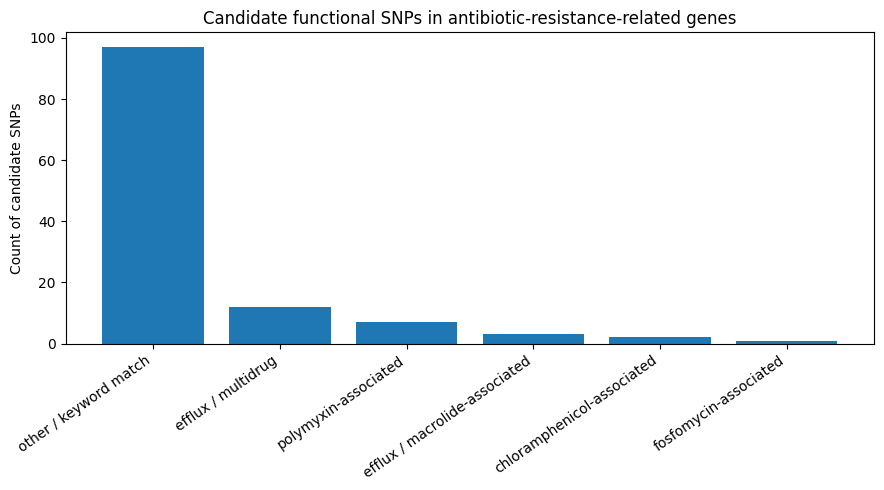

In [59]:
# простой график по механизмам

mech_counts = (
    priority_ar_snps["mechanism_group"]
    .value_counts()
)

plt.figure(figsize=(9, 5))
plt.bar(mech_counts.index, mech_counts.values)
plt.ylabel("Count of candidate SNPs")
plt.title("Candidate functional SNPs in antibiotic-resistance-related genes")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Для наглядности была построена диаграмма распределения потенциально значимых SNP по группам механизмов устойчивости. Это позволяет быстро увидеть, какие механизмы представлены в выборке сильнее.

In [60]:
print("Всего SNP в AR-кандидатах:", len(ar_snps))
print("Из них потенциально значимых:", len(priority_ar_snps))
print()
print("Топ-10 генов по числу кандидатных SNP:")
display(ar_gene_summary.head(10))
print()
print("Распределение по типам эффекта:")
display(priority_ar_snps["effect_type"].value_counts())
print()
print("Распределение по механизмам:")
display(priority_ar_snps["mechanism_group"].value_counts())

Всего SNP в AR-кандидатах: 921
Из них потенциально значимых: 122

Топ-10 генов по числу кандидатных SNP:


,gene,locus_tag,product,mechanism_group,candidate_snp_count,unique_aa_changes
31,mdtP,b4080,putative multidrug efflux pump outer membrane ...,other / keyword match,10,10
5,acrF,b3266,multidrug efflux pump RND permease AcrF,other / keyword match,9,9
17,marB,b1532,multiple antibiotic resistance protein MarB,other / keyword match,8,8
28,mdtM,b4337,multidrug efflux pump/bile salt:H(+) antiporte...,other / keyword match,8,8
27,mdtL,b3710,efflux pump MdtL,other / keyword match,7,7
30,mdtO,b4081,putative multidrug efflux pump subunit MdtO,efflux / multidrug,7,7
20,mdtC,b2076,multidrug efflux pump RND permease subunit MdtC,other / keyword match,5,5
21,mdtD,b2077,putative multidrug efflux pump MdtD,other / keyword match,5,5
1,aaeB,b3240,aromatic carboxylic acid efflux pump subunit AaeB,other / keyword match,4,4
7,arnA,b2255,fused UDP-4-amino-4-deoxy-L-arabinose formyltr...,polymyxin-associated,4,4



Распределение по типам эффекта:


,count
effect_type,
nonsynonymous,121
nonsense,1



Распределение по механизмам:


,count
mechanism_group,
other / keyword match,97
efflux / multidrug,12
polymyxin-associated,7
efflux / macrolide-associated,3
chloramphenicol-associated,2
fosfomycin-associated,1


### Выводы

Всего в AR-кандидатах было найдено 921 SNP, из них 122 оказались потенциально значимыми. Почти все такие замены были несинонимичными, то есть они могут влиять на аминокислотную последовательность белка. По распределению механизмов видно, что среди найденных кандидатов особенно заметны белки, связанные с эффлюксом и антибиотикорезистентностью по описанию продукта.

В итоге удалось выделить набор SNP-кандидатов, которые могут быть связаны с устойчивостью к антибиотикам. Это ещё не доказывает резистентность напрямую, но помогает понять, какие замены и какие гены выглядят наиболее важными.

